# **THE-BM3D-ALGORITHM**
Implementation of Block-Matching and 3D Filtering

Paper:
Marc Lebrun, An Analysis and Implementation of the BM3D Image Denoising Method, Image Processing On Line, 2 (2012), pp. 175–213. https://doi.org/10.5201/ipol.2012.l-bm3d

In [ ]:
import cv2
import numpy as np
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage

In [ ]:
from google.colab.patches import cv2_imshow
print(cv2.__version__)

4.13.0


# **Config params**

In [73]:
sigma = 25 # example value of standard deviation of the white Gaussian noise (WGN)
n_similar_patches=20
search_window=16
patch_size=8 # 8x8
threshold=0.1

In [28]:
image = cv2.imread('barbara.jpg')

# **Data preparation**

In [62]:
def add_gaussian_noise_to_image(input_image, mean=0, sigma_noise=sigma):
    """
    HINT: Converts image to grayscale if it is a color image, then adds Gaussian noise.

    Args:
    - input_image: Input image (either color or grayscale).
    - mean: Mean for Gaussian noise (default 0).
    - sigma_noise: Standard deviation for Gaussian noise.

    Returns:
    - Noisy grayscale image with Gaussian noise.
    """

    print("Sigma:", sigma_noise)

    print('Input image dimensions:', input_image.shape)

    # Convert to grayscale if needed
    if len(input_image.shape) == 3:
        gray_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

    print('Grayscale image dimensions:', gray_image.shape)

    # Add Gaussian noise
    np.random.seed(42)
    noise = sigma_noise * np.random.randn(*gray_image.shape)

    noisy_image = gray_image + noise

    print('Noisy image dimensions:', noisy_image.shape)

    return input_image, gray_image, noise, noisy_image

In [30]:
def display_images(images, titles=None):
    """
    Displays images in a single horizontal row with titles.

    Args:
    - images (list): List of images (numpy arrays).
    - titles (list, optional): List of titles for each image.

    Returns:
    - None
    """

    n = len(images)

    if titles is None:
        titles = [""] * n

    plt.figure(figsize=(4 * n, 4))

    for i in range(n):
        plt.subplot(1, n, i + 1)

        # Grayscale vs color handling
        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))

        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# **Metric**

In [32]:
# Function to compute the Euclidean distance between two patches
def compute_euclidean_distance(patch1, patch2):
    return np.linalg.norm(patch1 - patch2)

# **Step one**

In [33]:
# Block matching to find similar patches
def block_matching(image, patch_size, search_window, n_similar_patches):
    h, w = image.shape
    patches = []
    patch_locations = []

    # Extract patches - iterate through the image and extract reference patches from the image
    for y in range(0, h - patch_size + 1, patch_size):
        for x in range(0, w - patch_size + 1, patch_size):
            patch = image[y:y + patch_size, x:x + patch_size]
            patches.append(patch)
            patch_locations.append((y, x))

    # Find and group similar patches - for each reference patch, find the most similar patches within the search window
    patch_groups = []

    for ref_idx, (ref_patch, (y, x)) in enumerate(zip(patches, patch_locations)):
        similar_patches = []

        # Define the search window
        for j in range(max(0, y - search_window), min(h - patch_size, y + search_window)):
            for i in range(max(0, x - search_window), min(w - patch_size, x + search_window)):
                # Skip the current patch (reference patch) itself
                if i == x and j == y:
                    continue
                candidate_patch = image[j:j + patch_size, i:i + patch_size]
                dist = compute_euclidean_distance(ref_patch, candidate_patch)
                similar_patches.append((dist, candidate_patch, (j, i)))

        # Sort by similarity (Euclidean distance) and select the n most similar patches
        similar_patches.sort(key=lambda x: x[0])
        most_similar_patches = [patch for _, patch, _ in similar_patches[:n_similar_patches]]

        # Group the n most similar patches into a 3D tensor
        patch_groups.append(np.stack(most_similar_patches, axis=-1))

    return patch_groups, patch_locations

In [35]:
# Apply DCT, thresholding and IDCT to the patches
def dct_thresholding_idct(patch_groups, threshold):
    denoised_patches = []

    for group in patch_groups:
        # Apply DCT to each patch in the group
        dct_group = np.zeros_like(group, dtype=np.float32)

        for i in range(group.shape[-1]):  # Iterate over each patch in the group
            patch = group[..., i]
            dct_group[..., i] = cv2.dct(np.float32(patch))  # Apply DCT

        # Apply hard thresholding to DCT coefficients
        magnitude = np.abs(dct_group)
        dct_group[magnitude < threshold] = 0  # Set coefficients below threshold to 0

        # Apply IDCT to each patch in the group
        idct_group = np.zeros_like(group, dtype=np.float32)

        for i in range(group.shape[-1]):  # Iterate over each patch in the group
            idct_group[..., i] = cv2.idct(dct_group[..., i])  # Apply IDCT

        denoised_patches.append(idct_group)

    return denoised_patches

In [36]:
# Function to reconstruct the denoised image with aggregation
def reconstruct_image_from_patches_with_aggregation(denoised_patches, patch_size, image_size=(256, 256)):
    h, w = image_size
    reconstructed_image = np.zeros((h, w), dtype=np.float32)
    weight_map = np.zeros((h, w), dtype=np.float32)  # To track contributions to each pixel

    patch_idx = 0
    for y in range(0, h - patch_size + 1, patch_size):
        for x in range(0, w - patch_size + 1, patch_size):
            # Take the mean of the patches in the group to form the denoised patch
            patch = np.mean(denoised_patches[patch_idx], axis=-1)
            reconstructed_image[y:y + patch_size, x:x + patch_size] += patch
            weight_map[y:y + patch_size, x:x + patch_size] += 1
            patch_idx += 1

    # Normalize by the weight map to average overlapping patches
    reconstructed_image /= weight_map
    reconstructed_image = np.clip(reconstructed_image, 0, 255).astype(np.uint8)

    return reconstructed_image

# **Step two**


In [43]:
# Function to perform Wiener filtering with proper patch alignment
def wiener_filtering(group, basic_patch_group, threshold):
    """
    Perform Wiener filtering on the group of patches.

    Args:
    - group: Group of noisy patches.
    - basic_patch_group: Group of patches from the basic estimate.
    - threshold: Wiener filter threshold.

    Returns:
    - Wiener filtered group of patches.
    """
    filtered_group = np.zeros_like(group, dtype=np.float32)

    for i in range(group.shape[-1]):  # Iterate through each patch in the group
        noisy_patch = group[..., i]
        basic_patch = basic_patch_group[..., i]

        # Compute DCT of both noisy patch and basic patch
        dct_noisy_patch = cv2.dct(np.float32(noisy_patch))
        dct_basic_patch = cv2.dct(np.float32(basic_patch))

        # Wiener filtering in the DCT domain
        denominator = dct_basic_patch**2 + threshold
        dct_filtered = np.divide(dct_basic_patch**2 * dct_noisy_patch, denominator, where=denominator > 0)

        # Inverse DCT to reconstruct the filtered patch
        filtered_group[..., i] = cv2.idct(dct_filtered)

    return filtered_group

In [44]:
# Updated BM3D Step 2 function
def bm3d_step2(reconstructed_image1, basic_estimate, patch_size, search_window, n_similar_patches, threshold):
    """
    BM3D Step 2: Refine the estimate using Wiener filtering.

    Args:
    - noisy_image: Noisy input image.
    - basic_estimate: Denoised image from Step 1.
    - patch_size: Size of patches.
    - search_window: Search window size for block matching.
    - n_similar_patches: Number of similar patches.
    - threshold: Wiener filter threshold.

    Returns:
    - Final denoised image after Step 2.
    """
    h, w = reconstructed_image1.shape
    patch_groups, patch_locations = block_matching(reconstructed_image1, patch_size, search_window, n_similar_patches)
    basic_patch_groups, _ = block_matching(basic_estimate, patch_size, search_window, n_similar_patches)

    # Use Wiener filtering on each group of patches
    wiener_filtered_patches = []
    for group, basic_group in zip(patch_groups, basic_patch_groups):
        filtered_group = wiener_filtering(group, basic_group, threshold)
        wiener_filtered_patches.append(filtered_group)

    # Reconstruct the final image from Wiener filtered patches
    final_denoised_image = reconstruct_image_from_patches_with_aggregation(wiener_filtered_patches, patch_size, image_size=(h, w))

    return final_denoised_image

# **Results and visualization**

In [63]:
input_image, gray_image, noise, noisy_image = add_gaussian_noise_to_image(image, sigma_noise=sigma)

Sigma: 25
Input image dimensions: (512, 512, 3)
Grayscale image dimensions: (512, 512)
Noisy image dimensions: (512, 512)


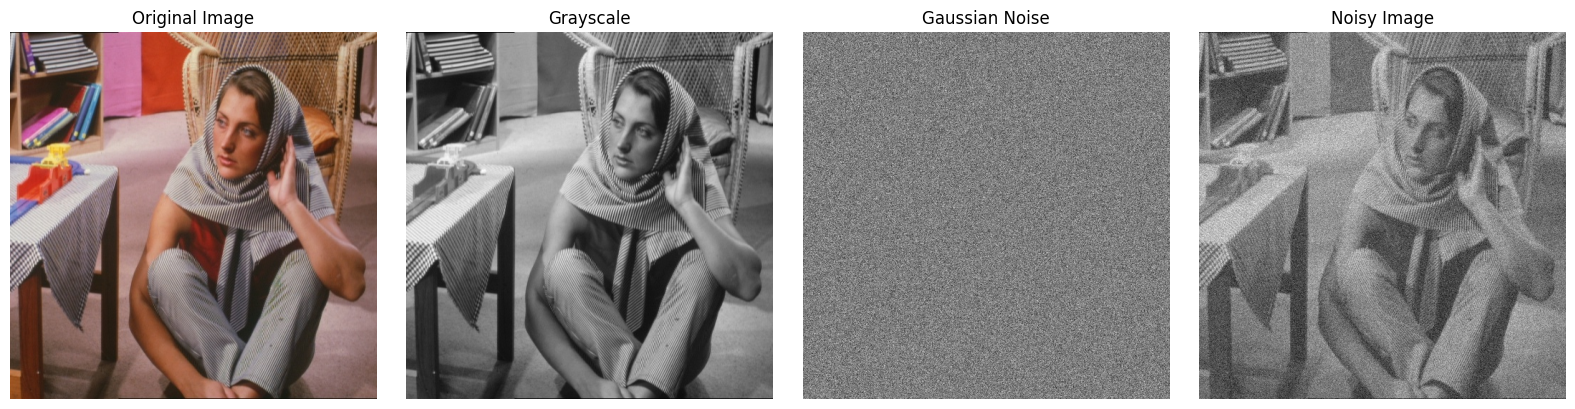

In [65]:
images = [input_image, gray_image, noise, noisy_image]
titles = ["Original Image", "Grayscale", "Gaussian Noise", "Noisy Image"]

display_images(images, titles)

In [66]:
# Apply Step 1
patch_groups, patch_locations = block_matching(noisy_image, patch_size, search_window, n_similar_patches)

# For demonstration, let's print out the shape of one of the 3D tensors
print(f"Shape of one patch group: {patch_groups[0].shape}")

Shape of one patch group: (8, 8, 20)


In [67]:
# Apply DCT, thresholding, and IDCT to denoise the patches
denoised_patches = dct_thresholding_idct(patch_groups, threshold)

In [68]:
# Reconstruct the denoised image from patches with aggregation
reconstructed_image1 = reconstruct_image_from_patches_with_aggregation(denoised_patches, patch_size=8, image_size=noisy_image.shape)

In [69]:
# Apply Step 2
final_denoised_image = bm3d_step2(noisy_image, reconstructed_image1, patch_size, search_window, n_similar_patches, threshold)

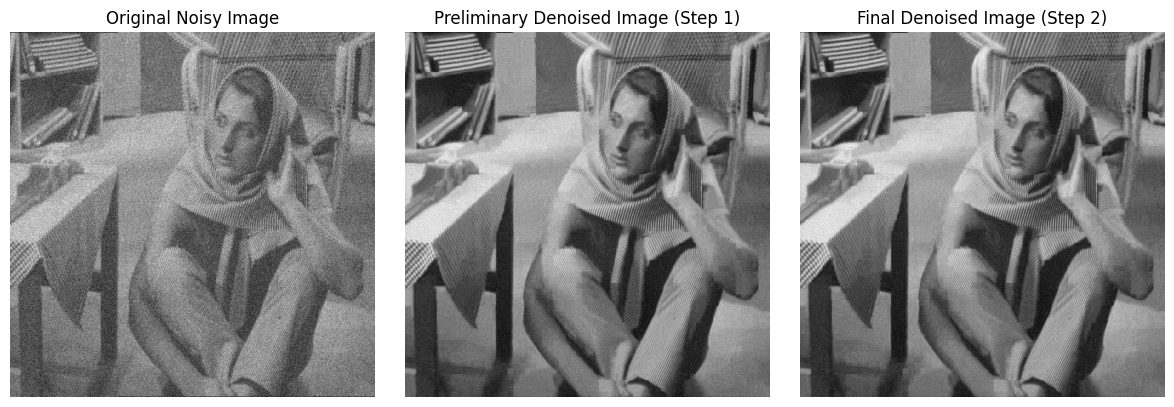

In [70]:
images = [noisy_image, reconstructed_image1, final_denoised_image]
titles = [
    "Original Noisy Image",
    "Preliminary Denoised Image (Step 1)",
    "Final Denoised Image (Step 2)"
]

display_images(images, titles)

# **Understanding the results**

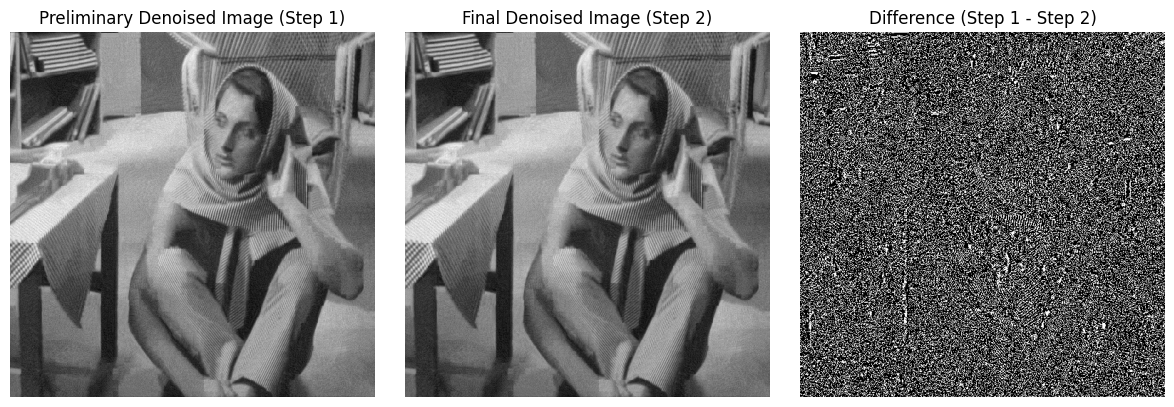

In [72]:
difference_image = reconstructed_image1 - final_denoised_image

images = [reconstructed_image1, final_denoised_image, difference_image]
titles = [
    "Preliminary Denoised Image (Step 1)",
    "Final Denoised Image (Step 2)",
    "Difference (Step 1 - Step 2)"
]

display_images(images, titles)